In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load & Overview of  the Dataset :

data = pd.read_csv("loan_approval_data.csv")

print(data.sample(5))
print(data.info())
print(data.describe())
print(data.isnull().sum())

     Applicant_ID  Applicant_Income  Coapplicant_Income Employment_Status  \
283         284.0               NaN              7314.0          Salaried   
416         417.0            7073.0               116.0     Self-employed   
546         547.0               NaN              2365.0               NaN   
783         784.0            7256.0              9654.0        Unemployed   
641         642.0            6777.0              1198.0          Salaried   

      Age Marital_Status  Dependents  Credit_Score  Existing_Loans  DTI_Ratio  \
283  43.0         Single         1.0         707.0             2.0       0.47   
416   NaN        Married         3.0         554.0             2.0       0.44   
546  22.0        Married         0.0         652.0             1.0       0.45   
783  52.0        Married         3.0         727.0             0.0       0.37   
641  23.0         Single         0.0         675.0             4.0       0.34   

     Savings  Collateral_Value  Loan_Amount  Loan_

# Handle Missing Values

In [3]:
categorical_cols = data.select_dtypes(include = ["object"]).columns
numerical_cols = data.select_dtypes(include = ["float64"]).columns

In [4]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [5]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [6]:
categorical_cols.size + numerical_cols.size

20

In [7]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

data[numerical_cols] = num_imputer.fit_transform(data[numerical_cols])
data[categorical_cols] = cat_imputer.fit_transform(data[categorical_cols])

In [8]:
print(data.isnull().sum())
data

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,997.0,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


# EDA

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64 <class 'pandas.core.series.Series'>


Text(0.5, 1.0, 'Loan Approval Status')

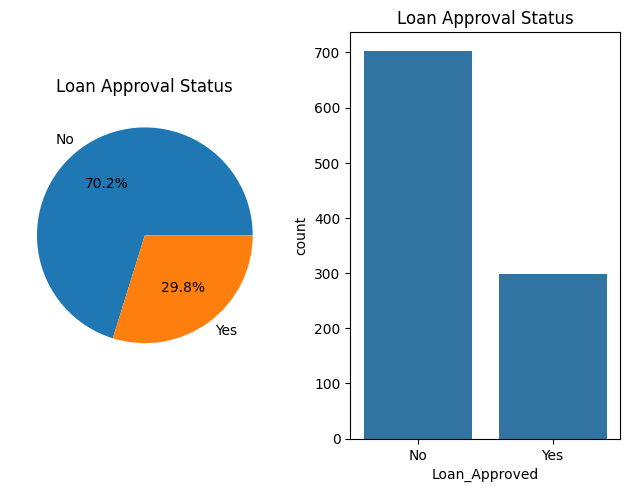

In [9]:
# Class Balance :

classes_counts = data["Loan_Approved"].value_counts()
print(classes_counts,type(classes_counts))

plt.subplot(1,2,1)
plt.pie(classes_counts,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Loan Approval Status")
plt.tight_layout()

plt.subplot(1,2,2)
sns.countplot(x=data["Loan_Approved"])
plt.tight_layout()
plt.title("Loan Approval Status")

Text(0.5, 1.0, 'Employment Status')

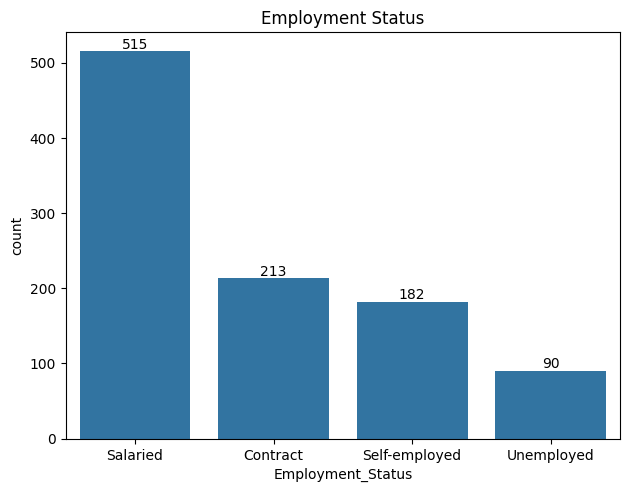

In [10]:
# Employement Status ;

employment_status_cnt = data["Employment_Status"].value_counts()
ax = sns.barplot(employment_status_cnt)
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.title("Employment Status")

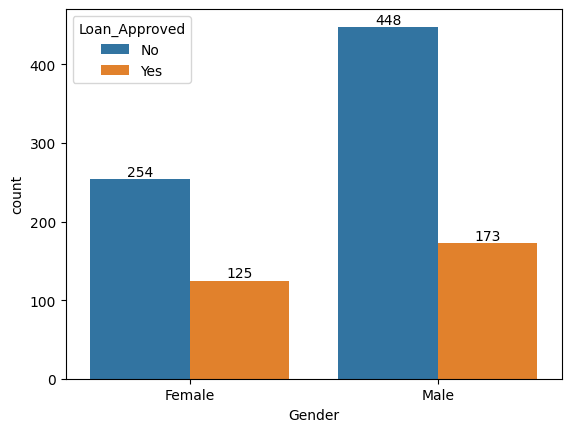

In [11]:
# Gender Split ;

# gen_count = data["Gender"].value_counts()
# ax = sns.barplot(gen_count)
# ax.bar_label(ax.containers[0])
# plt.tight_layout()
# plt.title("Applicant's Gender")

ax = sns.countplot(x="Gender",hue="Loan_Approved",data=data)

for container in ax.containers:
    ax.bar_label(container)

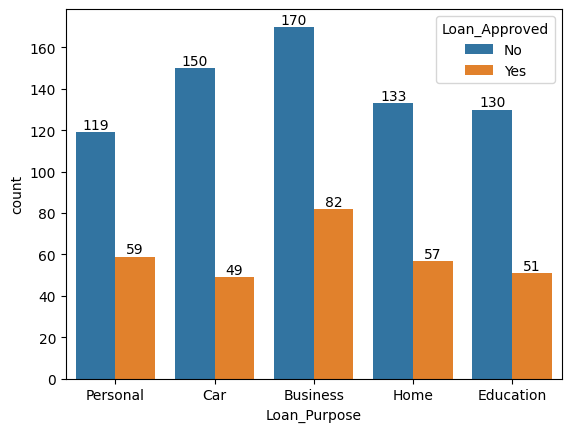

In [12]:
# Loan purpose effect on approval :

ax = sns.countplot(x="Loan_Purpose",hue="Loan_Approved",data=data)
# ax.bar_label(ax.containers[0])
# ax.bar_label(ax.containers[1])

for container in ax.containers:
    ax.bar_label(container)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

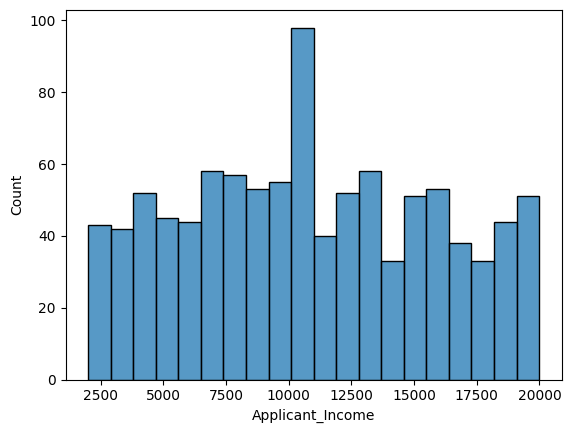

In [13]:
# Applicant Income Analysis :

sns.histplot(
    data = data,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

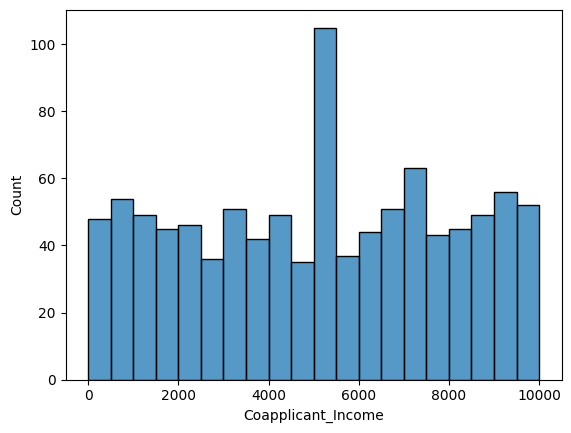

In [14]:
# Co - Applicant Income Analysis :

sns.histplot(
    data = data,
    x = "Coapplicant_Income",
    bins = 20
)

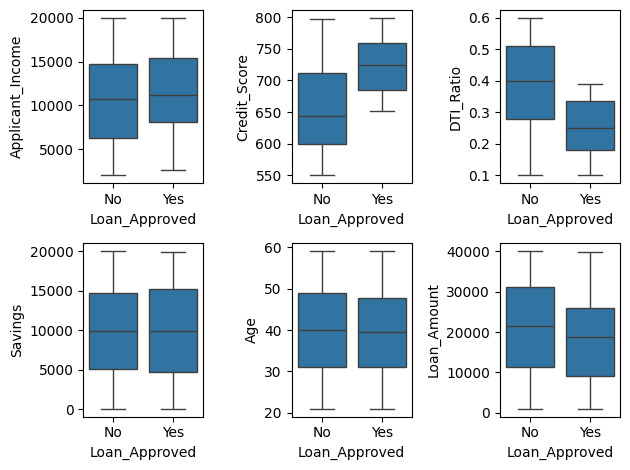

In [15]:
# Outlier Check : Box Plot

fig,axes = plt.subplots(2,3)

sns.boxplot(ax = axes[0,0], data = data,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[0,1], data = data,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[0,2], data = data,x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = axes[1,0], data = data,x = "Loan_Approved",y = "Savings")
sns.boxplot(ax = axes[1,1], data = data,x = "Loan_Approved",y = "Age")
sns.boxplot(ax = axes[1,2], data = data,x = "Loan_Approved",y = "Loan_Amount")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

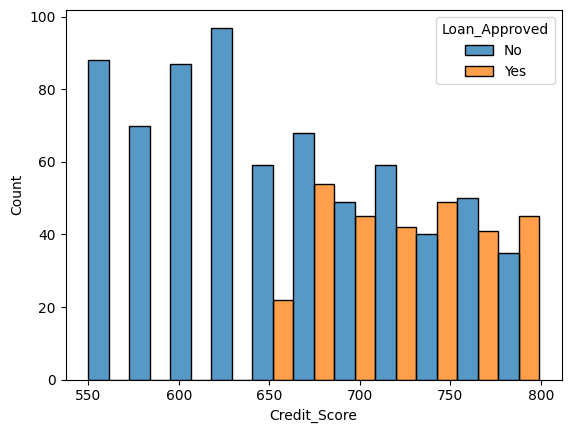

In [16]:
# Credit Score & Approval Status :

sns.histplot(
    x = "Credit_Score",
    data = data,
    hue = "Loan_Approved",
    multiple = "dodge"
)

In [17]:
# Remove the applicant ID to prevent the Overfitting :

data.drop("Applicant_ID",axis = 1, inplace = True)

# Encoding

In [18]:
# Label Encoding :

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["Education_Level"] = le.fit_transform(data["Education_Level"])
data["Loan_Approved"] = le.fit_transform(data["Loan_Approved"])

In [19]:
# One Hot Encoding :

from sklearn.preprocessing import OneHotEncoder

cols = ["Employment_Status", "Marital_Status","Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

leh = OneHotEncoder(sparse_output=False,handle_unknown="ignore",drop="first")
encoded = leh.fit_transform(data[cols])
encoded_col_name = leh.get_feature_names_out(cols)
encoded_df = pd.DataFrame(encoded,
                         columns = encoded_col_name,
                         index = data.index
)
data = data.drop(cols,axis = 1)
data = pd.concat([data,encoded_df],axis = 1)


In [21]:
data.head(2)

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
